# Scalar Viscous Burgers Equation: Plain Python Finite Elements, Adjoint, and Gradient
We now move from the forward scalar Burgers solve to the adjoint-based optimisation ingredients.


## The model problem

We study the **scalar viscous Burgers equation** on the interval $\Omega = (0,1)$ over the time interval $(0,T)$:

$$
\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} - \nu \frac{\partial^2 u}{\partial x^2} = m
\qquad \text{in } (0,T)\times\Omega,
$$

with homogeneous Dirichlet boundary conditions

$$
u(t,0)=u(t,1)=0,
$$

and initial condition

$$
u(0,x)=u_0(x).
$$

Here:

- $u=u(t,x)$ is the **state**,
- $m=m(t,x)$ is the **distributed control / source term**,
- $\nu>0$ is the **viscosity**.

To match the notation used in your dissertation, we keep the spatial spaces

$$
V := H_0^1(\Omega), \qquad M := L^2(\Omega).
$$

For a test function $v \in V$, the weak form at the continuous level is

$$
\int_\Omega u_t \, v \, dx
+
\int_\Omega u\,u_x\,v \, dx
+
\nu \int_\Omega u_x v_x \, dx
=
\int_\Omega m\,v \, dx.
$$

The nonlinear part is the convection term $u\,u_x$. This is the main new feature compared with the Poisson equation.

## Discretisation strategy

In this notebook we use:

- **P1 finite elements in space** on a uniform 1D mesh,
- **backward Euler in time**,
- **Newton iteration** at each time step.

So, given the previous solution $u^n$, we compute $u^{n+1}$ by solving the nonlinear weak problem

$$
\left(\frac{u^{n+1}-u^n}{\Delta t}, v\right)
+
(u^{n+1} (u^{n+1})_x, v)
+
\nu ((u^{n+1})_x, v_x)
=
(m^{n+1}, v)
\qquad \forall v \in V.
$$

Because this is nonlinear in $u^{n+1}$, we solve each time step with Newton's method.

The structure of the code is:

1. build a 1D mesh,
2. assemble the mass and stiffness matrices,
3. assemble the nonlinear convection residual and Jacobian,
4. march forward in time,
5. test the implementation with a manufactured exact solution.

In [1]:
import math
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

## Mesh and linear finite element assembly

We first build the basic ingredients for a 1D $P1$ finite element method:

- a uniform mesh on $(0,1)$,
- the global mass matrix,
- the global stiffness matrix,
- the load vector for a source term.

Nothing here is hidden inside a PDE library: the local element contributions are assembled directly into sparse global matrices.

In [2]:
def make_uniform_mesh_1d(num_elements, a=0.0, b=1.0):
    """
    Build a uniform 1D mesh on [a,b].

    Returns
    -------
    x : ndarray
        Array of node coordinates.
    elements : ndarray
        Each row contains the two node indices of one interval element.
    """
    x = np.linspace(a, b, num_elements + 1)
    elements = np.column_stack([np.arange(num_elements), np.arange(1, num_elements + 1)])
    return x, elements


def assemble_p1_mass_stiffness_1d(x, elements):
    """
    Assemble the global P1 mass and stiffness matrices on a 1D mesh.

    For each element [x_i, x_{i+1}] we use the standard local matrices

        M_e = (h/6) [[2, 1],
                     [1, 2]]

        K_e = (1/h) [[ 1, -1],
                     [-1,  1]]

    and then add them into sparse global matrices.
    """
    n_nodes = len(x)

    mass_rows, mass_cols, mass_vals = [], [], []
    stiff_rows, stiff_cols, stiff_vals = [], [], []

    mass_ref = np.array([[2.0, 1.0],
                         [1.0, 2.0]]) / 6.0
    stiff_ref = np.array([[1.0, -1.0],
                          [-1.0, 1.0]])

    for elem in elements:
        i, j = elem
        h = x[j] - x[i]

        M_loc = h * mass_ref
        K_loc = (1.0 / h) * stiff_ref

        for a in range(2):
            for b in range(2):
                mass_rows.append(elem[a])
                mass_cols.append(elem[b])
                mass_vals.append(M_loc[a, b])

                stiff_rows.append(elem[a])
                stiff_cols.append(elem[b])
                stiff_vals.append(K_loc[a, b])

    M = sp.csr_matrix((mass_vals, (mass_rows, mass_cols)), shape=(n_nodes, n_nodes))
    K = sp.csr_matrix((stiff_vals, (stiff_rows, stiff_cols)), shape=(n_nodes, n_nodes))
    return M, K


# Two-point Gauss quadrature on the reference interval [-1, 1].
GAUSS_POINTS = np.array([-1.0 / np.sqrt(3.0), 1.0 / np.sqrt(3.0)])
GAUSS_WEIGHTS = np.array([1.0, 1.0])


def assemble_load_vector(x, elements, source_fn, t):
    """
    Assemble the finite element load vector for the source/control term m(x,t).

    We use two-point Gauss quadrature on each element. For a 1D P1 method
    this is an accurate and simple choice for smooth data.
    """
    n_nodes = len(x)
    F = np.zeros(n_nodes)

    for elem in elements:
        i, j = elem
        x_left, x_right = x[i], x[j]
        h = x_right - x_left

        local = np.zeros(2)

        for xi, w in zip(GAUSS_POINTS, GAUSS_WEIGHTS):
            # Map the quadrature point from the reference interval to the physical element.
            x_q = 0.5 * (x_left + x_right) + 0.5 * h * xi

            # P1 basis functions on the reference interval.
            phi = np.array([(1.0 - xi) / 2.0, (1.0 + xi) / 2.0])

            local += w * float(source_fn(x_q, t)) * phi * (h / 2.0)

        F[elem] += local

    return F

## Nonlinear convection term

The Burgers nonlinearity is the term

$$
\int_\Omega u\,u_x\,v\,dx.
$$

Since we are using $P1$ finite elements in 1D, the derivative $u_x$ is constant on each element.  
That makes it possible to assemble the nonlinear term exactly at the element level.

For each Newton step we need:

- the **nonlinear residual contribution** from the convection term,
- the corresponding **Jacobian matrix**.

These are assembled below.

In [3]:
def assemble_convection_residual_and_jacobian(x, elements, U):
    """
    Assemble the nonlinear convection residual and its Jacobian.

    We treat the Burgers term in the form
        c(U; v) = integral of u_h * (u_h)_x * v_h over the domain.

    On each element, u_h is linear and (u_h)_x is constant, so the local
    contribution can be written down directly.

    Parameters
    ----------
    x : ndarray
        Mesh nodes.
    elements : ndarray
        Element connectivity.
    U : ndarray
        Current nodal values of the discrete solution.

    Returns
    -------
    R_conv : ndarray
        Global residual contribution from the convection term.
    J_conv : csr_matrix
        Global Jacobian contribution from the convection term.
    """
    n_nodes = len(x)

    R_conv = np.zeros(n_nodes)
    jac_rows, jac_cols, jac_vals = [], [], []

    mass_ref = np.array([[2.0, 1.0],
                         [1.0, 2.0]]) / 6.0

    # This vector extracts the derivative of a local linear function:
    # if u_loc = [u_i, u_{i+1}], then u_x = (-u_i + u_{i+1}) / h.
    derivative_vector = np.array([-1.0, 1.0])

    for elem in elements:
        i, j = elem
        h = x[j] - x[i]
        u_loc = U[elem]

        # Local mass matrix on this element.
        M_loc = h * mass_ref

        # q = \int u_h * phi_i dx in local-vector form.
        q = M_loc @ u_loc

        # Constant derivative of u_h on this element.
        grad_u = (derivative_vector @ u_loc) / h

        # Local nonlinear residual from u * u_x * v.
        R_loc = grad_u * q

        # Jacobian of the local nonlinear residual with respect to the two local dofs.
        J_loc = np.outer(q, derivative_vector) / h + grad_u * M_loc

        R_conv[elem] += R_loc

        for a in range(2):
            for b in range(2):
                jac_rows.append(elem[a])
                jac_cols.append(elem[b])
                jac_vals.append(J_loc[a, b])

    J_conv = sp.csr_matrix((jac_vals, (jac_rows, jac_cols)), shape=(n_nodes, n_nodes))
    return R_conv, J_conv

## Time stepping and Newton's method

We now put the pieces together.

At each time step we solve the nonlinear system

$$
M \frac{U^{n+1}-U^n}{\Delta t} + C(U^{n+1}) + \nu K U^{n+1} - F^{n+1} = 0,
$$

where:

- $M$ is the mass matrix,
- $K$ is the stiffness matrix,
- $C(U^{n+1})$ is the convection residual,
- $F^{n+1}$ is the load vector from the control/source term at the new time level.

We impose homogeneous Dirichlet boundary conditions by fixing the two boundary nodes to zero and solving only for the interior degrees of freedom.

In [4]:
def solve_forward_burgers_1d(
    num_elements=80,
    T=0.1,
    num_steps=400,
    nu=0.05,
    u0_fn=lambda x: np.sin(np.pi * x),
    source_fn=lambda x, t: 0.0,
    newton_tol=1e-10,
    max_newton_iters=25,
):
    """
    Solve the forward scalar viscous Burgers equation in 1D using:

    - P1 finite elements in space,
    - backward Euler in time,
    - Newton's method at each time step.

    Parameters
    ----------
    num_elements : int
        Number of mesh intervals.
    T : float
        Final time.
    num_steps : int
        Number of time steps.
    nu : float
        Viscosity parameter.
    u0_fn : callable
        Initial condition u(0,x).
    source_fn : callable
        Source/control function m(x,t).
    newton_tol : float
        Newton stopping tolerance based on the infinity norm of the update.
    max_newton_iters : int
        Maximum allowed Newton iterations per time step.

    Returns
    -------
    result : dict
        Dictionary containing mesh data, time grid, solution history,
        matrices, and Newton statistics.
    """
    x, elements = make_uniform_mesh_1d(num_elements)
    M, K = assemble_p1_mass_stiffness_1d(x, elements)

    dt = T / num_steps
    times = np.linspace(0.0, T, num_steps + 1)

    # Build the initial vector from the prescribed initial condition.
    U_prev = np.array([u0_fn(x_i) for x_i in x], dtype=float)

    # Enforce homogeneous Dirichlet boundary conditions at the two endpoints.
    U_prev[0] = 0.0
    U_prev[-1] = 0.0

    states = [U_prev.copy()]
    newton_iterations = []

    # The linear part of the Jacobian does not change from one Newton step to the next.
    linear_part = M / dt + nu * K

    for n in range(num_steps):
        t_next = times[n + 1]

        # Assemble the load vector for the source/control term at time t_{n+1}.
        F = assemble_load_vector(x, elements, source_fn, t_next)

        # Start Newton's method from the previous time-step solution.
        U = U_prev.copy()

        for k in range(max_newton_iters):
            # Nonlinear convection contribution and its Jacobian.
            C, J_C = assemble_convection_residual_and_jacobian(x, elements, U)

            # Full residual for the fully implicit backward Euler step.
            R = M @ ((U - U_prev) / dt) + C + nu * (K @ U) - F

            # Full Jacobian for Newton's method.
            J = linear_part + J_C

            # Solve only for the interior degrees of freedom.
            R_int = R[1:-1]
            J_int = J[1:-1, 1:-1]

            delta_int = spla.spsolve(J_int, -R_int)
            U[1:-1] += delta_int

            # Check convergence using the size of the Newton update.
            if np.linalg.norm(delta_int, ord=np.inf) < newton_tol:
                newton_iterations.append(k + 1)
                break
        else:
            raise RuntimeError(f"Newton did not converge at time step {n + 1}.")

        # Re-impose boundary values explicitly for safety/clarity.
        U[0] = 0.0
        U[-1] = 0.0

        states.append(U.copy())
        U_prev = U

    return {
        "x": x,
        "elements": elements,
        "times": times,
        "states": np.array(states),
        "M": M,
        "K": K,
        "dt": dt,
        "nu": nu,
        "newton_iterations": np.array(newton_iterations),
    }

## Manufactured solution test

To check that the implementation behaves sensibly, we use a smooth manufactured exact solution

$$
u_{\mathrm{exact}}(t,x) = e^{-t}\sin(\pi x).
$$

We then define the source term $m$ so that this exact solution satisfies the Burgers equation:

$$
m = u_t + u\,u_x - \nu u_{xx}.
$$

This gives us:

- an exact initial condition $u_0(x)=u_{\mathrm{exact}}(0,x)$,
- an exact control/source term $m(t,x)$,
- a way to compute numerical error at final time.

In [5]:
def manufactured_exact_solution(t, x):
    """Smooth exact solution used for testing."""
    return np.exp(-t) * np.sin(np.pi * x)


def manufactured_source(x, t, nu=0.05):
    """
    Source term chosen so that u_exact solves

        u_t + u u_x - nu u_xx = m.

    The exact solution is u_exact(t,x) = exp(-t) sin(pi x).
    """
    u = np.exp(-t) * np.sin(np.pi * x)
    u_x = np.exp(-t) * np.pi * np.cos(np.pi * x)
    u_xx = -np.exp(-t) * (np.pi ** 2) * np.sin(np.pi * x)
    u_t = -np.exp(-t) * np.sin(np.pi * x)

    return u_t + u * u_x - nu * u_xx


def compute_l2_error(x, elements, uh, exact_fn, t):
    """
    Compute the L2 error ||u_h - u_exact|| using element-wise quadrature.
    """
    error_sq = 0.0

    for elem in elements:
        i, j = elem
        x_left, x_right = x[i], x[j]
        h = x_right - x_left
        u_loc = uh[elem]

        for xi, w in zip(GAUSS_POINTS, GAUSS_WEIGHTS):
            x_q = 0.5 * (x_left + x_right) + 0.5 * h * xi
            phi = np.array([(1.0 - xi) / 2.0, (1.0 + xi) / 2.0])

            u_h_q = u_loc @ phi
            diff = u_h_q - exact_fn(t, x_q)
            error_sq += w * diff**2 * (h / 2.0)

    return math.sqrt(error_sq)

## One forward solve

We now run the solver on the manufactured test problem and compare the numerical and exact solutions at the final time.

In [6]:
# Problem parameters.
nu = 0.05
T = 0.1
num_elements = 80
num_steps = 8 * num_elements  # A simple choice that refines time and space together.

result = solve_forward_burgers_1d(
    num_elements=num_elements,
    T=T,
    num_steps=num_steps,
    nu=nu,
    u0_fn=lambda x: manufactured_exact_solution(0.0, x),
    source_fn=lambda x, t: manufactured_source(x, t, nu=nu),
)

x = result["x"]
times = result["times"]
states = result["states"]

u_final = states[-1]
u_exact_final = manufactured_exact_solution(T, x)
l2_error = compute_l2_error(result["x"], result["elements"], u_final, manufactured_exact_solution, T)

print(f"Final-time L2 error: {l2_error:.6e}")
print(f"Average Newton iterations per time step: {result['newton_iterations'].mean():.2f}")

Final-time L2 error: 8.700326e-05
Average Newton iterations per time step: 2.00


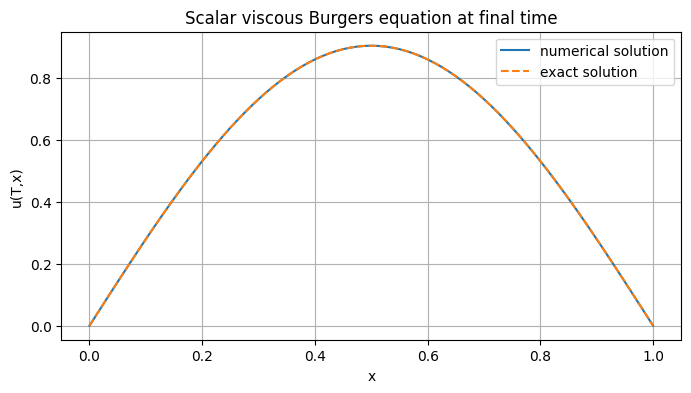

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(x, u_final, label="numerical solution")
plt.plot(x, u_exact_final, "--", label="exact solution")
plt.xlabel("x")
plt.ylabel("u(T,x)")
plt.title("Scalar viscous Burgers equation at final time")
plt.legend()
plt.grid(True)
plt.show()

The final-time numerical solution should lie very close to the manufactured exact solution.  
That is a good first check that the solver, nonlinear assembly, and time stepping are behaving correctly.

## Solution snapshots in time

It is also useful to look at the solution at several times. This gives a more qualitative picture of the evolution and lets us see that the solution remains smooth and respects the homogeneous boundary conditions.

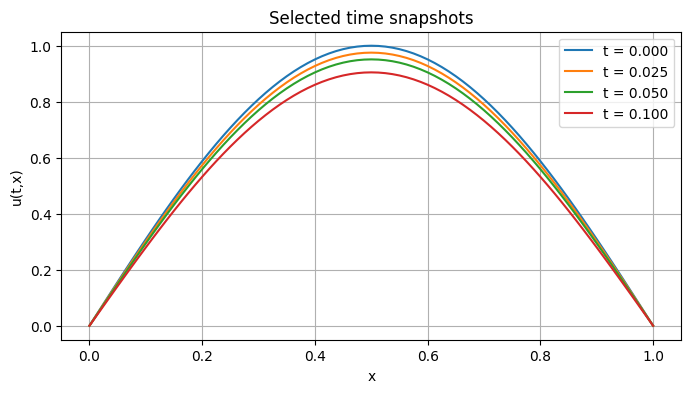

In [8]:
plt.figure(figsize=(8, 4))

snapshot_indices = [0, len(times) // 4, len(times) // 2, len(times) - 1]

for idx in snapshot_indices:
    plt.plot(x, states[idx], label=f"t = {times[idx]:.3f}")

plt.xlabel("x")
plt.ylabel("u(t,x)")
plt.title("Selected time snapshots")
plt.legend()
plt.grid(True)
plt.show()

## Forward convergence tests

To mirror the Poisson workflow more closely, we now make the Burgers verification section
a little more systematic.

Because we have chosen a manufactured exact solution, we can measure error in more than one way.
In particular, we will report

1. the **final-time** \(L^2(\Omega)\)-error \(\|u_h(T)-u(T)\|_{L^2(\Omega)}\), and
2. a **discrete space-time** error built from the time grid,
   $$
   \left(\Delta t \sum_{n=1}^N \|u_h^n-u(t_n)\|_{L^2(\Omega)}^2\right)^{1/2}.
   $$

The second quantity is not a full continuous-in-time norm. It is simply the natural
fully discrete analogue for the backward Euler scheme used in the notebook.

As in the earlier Poisson notebook, the point here is not to prove a theorem.  
The point is to check that the errors decrease cleanly under refinement and to record
observed convergence rates.


In [9]:

def compute_discrete_space_time_l2_error(result, exact_fn):
    """
    Compute the discrete-in-time space-time error

        (dt * sum_n ||u_h^n - u(t_n)||_{L2(Ω)}^2)^{1/2}.

    This is a practical fully discrete error measure that uses the same spatial
    quadrature-based L2 error routine as the final-time study.
    """
    dt = result["dt"]
    x = result["x"]
    elements = result["elements"]
    states = result["states"]
    times = result["times"]

    error_sq = 0.0
    for U_n, t_n in zip(states[1:], times[1:]):
        slice_error = compute_l2_error(x, elements, U_n, exact_fn, t_n)
        error_sq += dt * slice_error**2

    return math.sqrt(error_sq)


def run_burgers_convergence_tests(mesh_sizes=(10, 20, 40, 80), T=0.1, nu=0.05, steps_per_element=8):
    """
    Run refinement tests for the manufactured Burgers problem.

    We refine space and time together by taking
        num_steps = steps_per_element * num_elements,
    which keeps dt proportional to h on the unit interval.

    The returned table reports:
    - h,
    - the final-time L2 error,
    - the discrete space-time L2 error,
    - observed rates for both errors,
    - and the average number of Newton iterations per step.
    """
    rows = []
    previous_final = None
    previous_spacetime = None

    for N in mesh_sizes:
        num_steps = steps_per_element * N

        result = solve_forward_burgers_1d(
            num_elements=N,
            T=T,
            num_steps=num_steps,
            nu=nu,
            u0_fn=lambda x: manufactured_exact_solution(0.0, x),
            source_fn=lambda x, t: manufactured_source(x, t, nu=nu),
        )

        final_error = compute_l2_error(
            result["x"],
            result["elements"],
            result["states"][-1],
            manufactured_exact_solution,
            T,
        )
        spacetime_error = compute_discrete_space_time_l2_error(
            result,
            manufactured_exact_solution,
        )

        final_rate = np.nan if previous_final is None else math.log(previous_final / final_error, 2.0)
        spacetime_rate = np.nan if previous_spacetime is None else math.log(previous_spacetime / spacetime_error, 2.0)

        rows.append(
            {
                "num_elements": N,
                "num_steps": num_steps,
                "h": 1.0 / N,
                "final_time_L2_error": final_error,
                "final_time_rate": final_rate,
                "discrete_space_time_L2_error": spacetime_error,
                "space_time_rate": spacetime_rate,
                "avg_newton_iters": result["newton_iterations"].mean(),
            }
        )

        previous_final = final_error
        previous_spacetime = spacetime_error

    return pd.DataFrame(rows)


convergence_df = run_burgers_convergence_tests()
convergence_df


,num_elements,num_steps,h,final_time_L2_error,final_time_rate,discrete_space_time_L2_error,space_time_rate,avg_newton_iters
0,10,80,0.1000,0.005840,NaN,0.001838,NaN,3.0
1,20,160,0.0500,0.001452,2.007670,0.000459,2.002745,3.0
2,40,320,0.0250,0.000358,2.019717,0.000114,2.009816,2.0
3,80,640,0.0125,0.000087,2.041441,0.000028,2.020882,2.0


The table above should show both error measures decreasing as the mesh is refined.

A useful visual check is a log-log plot of the error against the mesh size \(h\).
If the method is behaving well, the curves should slope downward in a reasonably regular way,
and the rate columns in the table should not jump around wildly.

The point of this section is the same as in your Poisson notebook:
before trusting adjoints and gradients, first make sure the forward solver itself behaves sensibly.


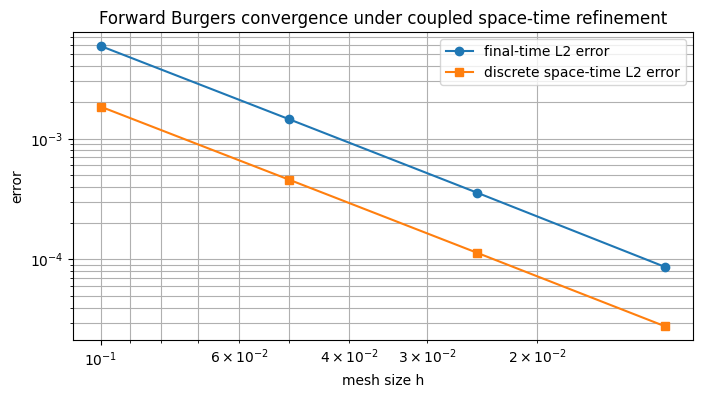

In [10]:

plt.figure(figsize=(8, 4))
plt.loglog(convergence_df["h"], convergence_df["final_time_L2_error"], marker="o", label="final-time L2 error")
plt.loglog(convergence_df["h"], convergence_df["discrete_space_time_L2_error"], marker="s", label="discrete space-time L2 error")
plt.gca().invert_xaxis()
plt.xlabel("mesh size h")
plt.ylabel("error")
plt.title("Forward Burgers convergence under coupled space-time refinement")
plt.legend()
plt.grid(True, which="both")
plt.show()


## What this notebook gives you

This notebook now contains the same overall ingredients you built for Poisson, but for
a **by-hand scalar viscous Burgers problem**:

- an explicitly assembled forward finite element solver,
- a manufactured-solution test,
- forward convergence tests under refinement,
- a discrete tracking objective,
- a discrete adjoint solved backward in time,
- a discrete gradient,
- and a Taylor-style gradient check.

So this notebook now does more than simply ``solve Burgers''.
It gives you a first complete **verification-and-optimisation pipeline** for Burgers
before any later Firedrake version.



## Discrete control problem

We now keep the same **by-hand finite element / plain Python** approach, but add the optimisation ingredients.

The continuous model problem is the scalar viscous Burgers equation
$$
u_t + u u_x - \nu u_{xx} = m,
$$
with homogeneous Dirichlet boundary conditions and a prescribed initial condition.

For the optimisation part of the notebook we discretise the control in the same nodal
$P1$ finite element space as the state at each time level. This means that, at each
implicit time step, the control is represented by a vector of nodal values.

We then consider the fully discrete tracking-type objective
$$
J_h(u_h,m_h)
=
\frac{\Delta t}{2}\sum_{n=1}^N \|u_h^n-d_h^n\|_{L^2(\Omega)}^2
+
\frac{\alpha\Delta t}{2}\sum_{n=1}^N \|m_h^n\|_{L^2(\Omega)}^2.
$$

The key point is that we now derive and implement the **discrete adjoint** of the fully
discrete scheme that we actually solve in code. This is a very natural choice in a
hand-written notebook, because the adjoint then matches the forward discretisation step
for step.


In [11]:

def build_control_history_from_callable(x, times, control_fn):
    """
    Sample a time-dependent control at the mesh nodes for each implicit time level t_{n+1}.

    The result is an array of shape (num_steps, num_nodes), where row n contains the
    nodal values of the control used in the step from t_n to t_{n+1}.
    """
    control_history = np.zeros((len(times) - 1, len(x)))

    for n, t in enumerate(times[1:]):
        control_history[n] = np.array([control_fn(x_i, t) for x_i in x], dtype=float)

    return control_history


def solve_forward_burgers_with_control(
    num_elements=80,
    T=0.2,
    num_steps=200,
    nu=0.05,
    u0_fn=lambda x: 0.0,
    control_history=None,
    control_fn=None,
    newton_tol=1e-10,
    max_newton_iters=25,
):
    """
    Solve the forward scalar viscous Burgers equation with a distributed control m.

    Compared with the earlier forward solver, the source term is now represented directly
    by a time history of nodal control coefficients. At each time step we assemble the
    load vector simply as M @ m^n, because m^n is itself stored in the same P1 space.

    Returns
    -------
    result : dict
        Mesh data, mass and stiffness matrices, the time grid, the state history,
        the control history, and Newton iteration counts.
    """
    x, elements = make_uniform_mesh_1d(num_elements)
    M, K = assemble_p1_mass_stiffness_1d(x, elements)

    dt = T / num_steps
    times = np.linspace(0.0, T, num_steps + 1)

    if control_history is None:
        if control_fn is None:
            control_fn = lambda x, t: 0.0
        control_history = build_control_history_from_callable(x, times, control_fn)
    else:
        control_history = np.asarray(control_history, dtype=float)
        expected_shape = (num_steps, len(x))
        if control_history.shape != expected_shape:
            raise ValueError(
                f"control_history should have shape {expected_shape}, got {control_history.shape}."
            )

    # Build and enforce the initial condition.
    U_prev = np.array([u0_fn(x_i) for x_i in x], dtype=float)
    U_prev[0] = 0.0
    U_prev[-1] = 0.0

    states = [U_prev.copy()]
    newton_iterations = []

    # The linear part of the Jacobian stays fixed across Newton iterations.
    linear_part = M / dt + nu * K

    for n in range(num_steps):
        # Since the control is represented in the finite element basis, the load vector is M @ m^n.
        F = M @ control_history[n]

        # Use the previous time step as the Newton initial guess.
        U = U_prev.copy()

        for k in range(max_newton_iters):
            C, J_C = assemble_convection_residual_and_jacobian(x, elements, U)

            # Fully discrete backward Euler residual:
            #     M (U^n - U^{n-1}) / dt + C(U^n) + nu K U^n - M m^n = 0.
            R = M @ ((U - U_prev) / dt) + C + nu * (K @ U) - F
            J = linear_part + J_C

            # We solve only for the interior degrees of freedom because the boundary values are fixed.
            R_int = R[1:-1]
            J_int = J[1:-1, 1:-1]

            delta_int = spla.spsolve(J_int, -R_int)
            U[1:-1] += delta_int

            if np.linalg.norm(delta_int, ord=np.inf) < newton_tol:
                newton_iterations.append(k + 1)
                break
        else:
            raise RuntimeError(f"Newton did not converge at time step {n + 1}.")

        U[0] = 0.0
        U[-1] = 0.0

        states.append(U.copy())
        U_prev = U

    return {
        "x": x,
        "elements": elements,
        "M": M,
        "K": K,
        "dt": dt,
        "times": times,
        "nu": nu,
        "states": np.array(states),
        "control_history": control_history,
        "newton_iterations": np.array(newton_iterations),
    }



## Objective functional, discrete adjoint, and gradient

Once the forward model is fully discrete, the cleanest next step is to derive the
**discrete adjoint** of that scheme.

At time level $n$, the fully discrete forward residual is
$$
R_n(U^n,U^{n-1},m^n)
=
M \frac{U^n-U^{n-1}}{\Delta t}
+
C(U^n)
+
\nu K U^n
-
M m^n.
$$

The discrete objective is
$$
J_h(U,m)
=
\frac{\Delta t}{2}\sum_{n=1}^N (U^n-D^n)^T M (U^n-D^n)
+
\frac{\alpha \Delta t}{2}\sum_{n=1}^N (m^n)^T M m^n.
$$

If we introduce a discrete adjoint variable \(p^n\) and differentiate the discrete
Lagrangian, the backward adjoint recursion takes the form
$$
A_n^T p^n
=
\Delta t\, M (U^n-D^n)
+
\frac{1}{\Delta t} M p^{n+1},
$$
with terminal condition \(p^{N+1}=0\), where
$$
A_n
=
\frac{1}{\Delta t} M + \nu K + J_C(U^n)
$$
is the Jacobian of the fully discrete Burgers residual with respect to the current state.

For the mass-matrix-weighted \(L^2\)-type control inner product, the resulting discrete
gradient is
$$
\nabla J_h(m)^n = \alpha m^n + \frac{1}{\Delta t} p^n.
$$

So the notebook below mirrors the same logic you already used in the Poisson project:

1. solve the forward problem,
2. solve the adjoint problem,
3. compute the gradient,
4. verify the gradient with a Taylor-style check.


In [12]:

def evaluate_tracking_objective(result, target_history, alpha):
    """
    Evaluate the fully discrete tracking objective

        J_h = (dt/2) sum_n ||U^n - D^n||_M^2 + (alpha dt/2) sum_n ||m^n||_M^2.

    Here ||v||_M^2 means v^T M v, the finite element analogue of the L2 norm.
    """
    M = result["M"]
    dt = result["dt"]

    states = result["states"][1:]          # Exclude the initial condition U^0.
    control_history = result["control_history"]
    target_history = np.asarray(target_history, dtype=float)

    if target_history.shape != states.shape:
        raise ValueError(
            f"target_history should have shape {states.shape}, got {target_history.shape}."
        )

    total = 0.0
    for U_n, D_n, m_n in zip(states, target_history, control_history):
        state_error = U_n - D_n
        total += 0.5 * dt * (state_error @ (M @ state_error))
        total += 0.5 * alpha * dt * (m_n @ (M @ m_n))

    return float(total)


def solve_discrete_adjoint(result, target_history):
    """
    Solve the discrete adjoint equation backward in time.

    This adjoint matches the fully discrete forward scheme in the notebook, rather than
    first writing a continuous adjoint PDE and then discretising it afterwards.
    """
    x = result["x"]
    elements = result["elements"]
    M = result["M"]
    K = result["K"]
    dt = result["dt"]
    nu = result["nu"]
    states = result["states"]

    num_steps = len(result["times"]) - 1
    target_history = np.asarray(target_history, dtype=float)

    # Store one adjoint vector per time level t_1, ..., t_N.
    adjoints = np.zeros((num_steps, len(x)))

    # This stores p^{n+1} as we sweep backwards.
    p_next = np.zeros(len(x))

    for n in reversed(range(num_steps)):
        U_n = states[n + 1]

        # Rebuild the Jacobian of the nonlinear convection term at the converged forward state U^n.
        _, J_conv = assemble_convection_residual_and_jacobian(x, elements, U_n)
        A_n = M / dt + nu * K + J_conv

        # Right-hand side of the backward discrete adjoint equation.
        rhs = dt * (M @ (U_n - target_history[n]))
        if n < num_steps - 1:
            rhs += (M @ p_next) / dt

        # The adjoint also satisfies homogeneous Dirichlet conditions, so again we solve only inside.
        p_int = spla.spsolve(A_n[1:-1, 1:-1].T, rhs[1:-1])

        adjoints[n, 1:-1] = p_int
        p_next = adjoints[n].copy()

    return adjoints


def compute_discrete_l2_gradient(result, target_history, alpha):
    """
    Compute the mass-matrix-weighted discrete gradient

        grad^n = alpha m^n + p^n / dt.

    This is the discrete analogue of the familiar formula "adjoint + alpha times control".
    """
    adjoints = solve_discrete_adjoint(result, target_history)
    gradient = alpha * result["control_history"] + adjoints / result["dt"]
    return gradient, adjoints


def control_inner_product(control_a, control_b, M, dt):
    """
    Discrete control inner product:
        <a, b> = dt * sum_n a_n^T M b_n.

    This plays the role of the L2 inner product over space-time.
    """
    total = 0.0
    for a_n, b_n in zip(control_a, control_b):
        total += dt * (a_n @ (M @ b_n))
    return float(total)



## Build a target trajectory from a reference control

To keep the optimisation test self-contained, we first choose a smooth **reference control**
and solve the forward problem once. The resulting state trajectory becomes the desired state
for the tracking functional.

We then choose a different trial control and evaluate the objective, adjoint, and gradient
at that trial point.


In [13]:

# A modest problem size keeps the notebook fast enough for repeated solves in the Taylor test.
num_elements = 20
T = 0.2
num_steps = 60
nu = 0.05
alpha = 1.0e-3

u0_fn = lambda x: 0.0

# We first define a smooth reference control. Its forward solution will become our target state.
def reference_control_fn(x, t):
    return 0.5 * np.sin(np.pi * x) * (1.0 + 0.2 * np.cos(2.0 * np.pi * t / T))


# We also define a different trial control. This is the point at which we will compute the gradient.
def trial_control_fn(x, t):
    return 0.15 * np.sin(2.0 * np.pi * x) * np.exp(-2.0 * t) + 0.05 * np.sin(np.pi * x)


# Use a temporary mesh/time grid to sample the two controls.
x_tmp, _ = make_uniform_mesh_1d(num_elements)
times_tmp = np.linspace(0.0, T, num_steps + 1)

reference_control_history = build_control_history_from_callable(x_tmp, times_tmp, reference_control_fn)
trial_control_history = build_control_history_from_callable(x_tmp, times_tmp, trial_control_fn)

# Solve the forward problem for the reference control and use the resulting state as the desired state.
reference_result = solve_forward_burgers_with_control(
    num_elements=num_elements,
    T=T,
    num_steps=num_steps,
    nu=nu,
    u0_fn=u0_fn,
    control_history=reference_control_history,
)

target_history = reference_result["states"][1:].copy()

# Now solve the forward problem for the trial control.
trial_result = solve_forward_burgers_with_control(
    num_elements=num_elements,
    T=T,
    num_steps=num_steps,
    nu=nu,
    u0_fn=u0_fn,
    control_history=trial_control_history,
)

gradient_history, adjoint_history = compute_discrete_l2_gradient(
    trial_result,
    target_history,
    alpha=alpha,
)

objective_value = evaluate_tracking_objective(trial_result, target_history, alpha=alpha)

print(f"Objective value J_h(m): {objective_value:.6e}")
print(f"Average Newton iterations in the trial forward solve: {trial_result['newton_iterations'].mean():.2f}")


Objective value J_h(m): 1.323574e-04
Average Newton iterations in the trial forward solve: 3.00



## Inspect the forward state, target state, control, adjoint, and gradient

The first plot compares the final-time forward state for the **trial control** against the
desired final-time target state. The second plot shows one representative time slice of the
control, adjoint, and gradient. This is useful for building intuition before doing a formal
Taylor test.


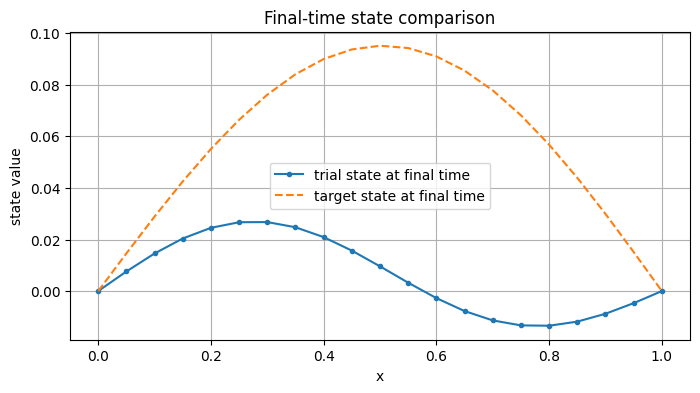

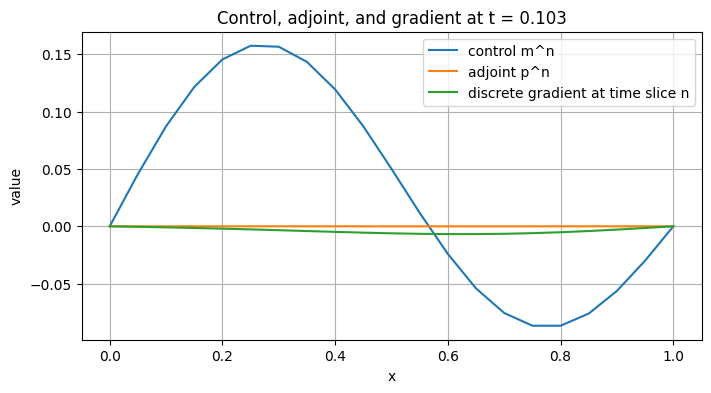

In [14]:

x = trial_result["x"]
times = trial_result["times"]

# Choose a representative interior time level for plotting.
mid_index = num_steps // 2

plt.figure(figsize=(8, 4))
plt.plot(x, trial_result["states"][-1], marker="o", ms=3, label="trial state at final time")
plt.plot(x, target_history[-1], linestyle="--", label="target state at final time")
plt.xlabel("x")
plt.ylabel("state value")
plt.title("Final-time state comparison")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(x, trial_control_history[mid_index], label="control m^n")
plt.plot(x, adjoint_history[mid_index], label="adjoint p^n")
plt.plot(x, gradient_history[mid_index], label="discrete gradient at time slice n")
plt.xlabel("x")
plt.ylabel("value")
plt.title(f"Control, adjoint, and gradient at t = {times[mid_index + 1]:.3f}")
plt.legend()
plt.grid(True)
plt.show()



## Taylor-style gradient check

The standard practical test is to choose a perturbation direction \(\delta m\) and check
that
$$
J_h(m+h\,\delta m) - J_h(m) - h\, dJ_h(m;\delta m)
$$
decays like \(O(h^2)\) as \(h \to 0\).

In this notebook, the directional derivative is computed from the discrete gradient using the
control inner product
$$
dJ_h(m;\delta m) = \langle \nabla J_h(m), \delta m \rangle.
$$

A clean second-order decay in the remainder is strong evidence that the adjoint and gradient
have been implemented correctly.


In [15]:

def reduced_objective_only(
    control_history,
    num_elements,
    T,
    num_steps,
    nu,
    u0_fn,
    target_history,
    alpha,
):
    """Solve the forward problem for a given control and return the reduced objective."""
    result = solve_forward_burgers_with_control(
        num_elements=num_elements,
        T=T,
        num_steps=num_steps,
        nu=nu,
        u0_fn=u0_fn,
        control_history=control_history,
    )
    return evaluate_tracking_objective(result, target_history, alpha)


def run_burgers_taylor_test(
    base_control_history,
    direction_history,
    target_history,
    num_elements,
    T,
    num_steps,
    nu,
    u0_fn,
    alpha,
    h_values=(1e-1, 5e-2, 2.5e-2, 1.25e-2, 6.25e-3),
):
    """
    Run a Taylor-style gradient test for the reduced objective.

    We return a DataFrame showing:
    - the zeroth-order difference |J(m+h dm) - J(m)|,
    - the second-order remainder |J(m+h dm) - J(m) - h dJ(m;dm)|,
    - and observed rates under halving of h.
    """
    base_result = solve_forward_burgers_with_control(
        num_elements=num_elements,
        T=T,
        num_steps=num_steps,
        nu=nu,
        u0_fn=u0_fn,
        control_history=base_control_history,
    )

    J0 = evaluate_tracking_objective(base_result, target_history, alpha)
    gradient, _ = compute_discrete_l2_gradient(base_result, target_history, alpha)

    # Normalise the perturbation direction in the control inner product.
    direction_norm = np.sqrt(control_inner_product(direction_history, direction_history, base_result["M"], base_result["dt"]))
    direction_unit = direction_history / direction_norm

    directional_derivative = control_inner_product(
        gradient,
        direction_unit,
        base_result["M"],
        base_result["dt"],
    )

    rows = []
    previous_first = None
    previous_second = None

    for h in h_values:
        Jh = reduced_objective_only(
            base_control_history + h * direction_unit,
            num_elements=num_elements,
            T=T,
            num_steps=num_steps,
            nu=nu,
            u0_fn=u0_fn,
            target_history=target_history,
            alpha=alpha,
        )

        first_remainder = abs(Jh - J0)
        second_remainder = abs(Jh - J0 - h * directional_derivative)

        first_rate = np.nan if previous_first is None else np.log(previous_first / first_remainder) / np.log(2.0)
        second_rate = np.nan if previous_second is None else np.log(previous_second / second_remainder) / np.log(2.0)

        rows.append(
            {
                "h": h,
                "|J(m+h dm)-J(m)|": first_remainder,
                "first-order rate": first_rate,
                "|J(m+h dm)-J(m)-h dJ|": second_remainder,
                "second-order rate": second_rate,
            }
        )

        previous_first = first_remainder
        previous_second = second_remainder

    return pd.DataFrame(rows), directional_derivative


# Build a smooth perturbation direction.
direction_history = np.zeros_like(trial_control_history)
for n, t in enumerate(times_tmp[1:]):
    direction_history[n] = (
        np.sin(np.pi * x_tmp) * (1.0 + 0.1 * np.cos(3.0 * np.pi * t / T))
        + 0.3 * np.sin(2.0 * np.pi * x_tmp)
    )

taylor_df, directional_derivative = run_burgers_taylor_test(
    base_control_history=trial_control_history,
    direction_history=direction_history,
    target_history=target_history,
    num_elements=num_elements,
    T=T,
    num_steps=num_steps,
    nu=nu,
    u0_fn=u0_fn,
    alpha=alpha,
)

print(f"Directional derivative from the discrete gradient: {directional_derivative:.6e}")
taylor_df


Directional derivative from the discrete gradient: -1.548497e-03


,h,|J(m+h dm)-J(m)|,first-order rate,|J(m+h dm)-J(m)-h dJ|,second-order rate
0,0.10000,0.000088,NaN,6.731694e-05,NaN
1,0.05000,0.000061,0.530575,1.682780e-05,2.000123
2,0.02500,0.000035,0.812414,4.206766e-06,2.000063
3,0.01250,0.000018,0.914631,1.051668e-06,2.000032
4,0.00625,0.000009,0.959139,2.629140e-07,2.000016



A good sign is that the **second-order remainder** should decay with an observed rate
close to **2** when the gradient is implemented correctly.

So, in practical terms, this notebook now gives you the full by-hand scalar Burgers chain:

1. assemble and solve the forward problem,
2. build the tracking functional,
3. solve the discrete adjoint backward in time,
4. compute the discrete gradient,
5. verify that gradient with a Taylor-style test.

That is exactly the same overall optimisation pipeline you already built for Poisson, but
now in a genuinely **nonlinear** and **time-dependent** setting.
